SVM
----------------------------------------------------------------------------------------------
Theory 

Support Vector Machine is a supervised machine learning algorithm mainly used for classification. The main idea of SVM is to find the best decision boundary, called a hyperplane, that separates data points of different classes. In two-dimensional space, this hyperplane is a line, while in higher dimensions it becomes a plane or hyperplane. The equation of the hyperplane is:

w
T
x+b=0

where w is the weight vector, x is the input feature vector, and b is the bias. A data point is classified based on the sign of w
T
x+b. If the value is positive, it belongs to one class, and if it is negative, it belongs to the other class.

The main objective of SVM is to maximize the margin between two classes. The margin is the distance between the decision boundary and the nearest data points from each class. These nearest points are known as support vectors because they determine the position of the decision boundary. For hard margin SVM, all data points must be correctly classified and lie outside the margin. The condition is:

y
i
	​

(w
T
x
i
	​

+b)≥1

and the optimization problem is:

Minimize 
2
1
	​

∣∣w∣∣
2

This makes the margin as wide as possible. However, hard margin SVM works properly only when the data is linearly separable.

In real-world data, classes may overlap or contain noise. Therefore, soft margin SVM is used. Soft margin SVM allows some misclassification by introducing slack variables ξ
i
	​

. Its optimization problem is:

Minimize 
2
1
	​

∣∣w∣∣
2
+C
i=1
∑
n
	​

ξ
i
	​


subject to:

y
i
	​

(w
T
x
i
	​

+b)≥1−ξ
i
	​


Here, C is a regularization parameter that controls the balance between maximizing the margin and reducing classification errors. A large value of C gives more importance to correct classification, while a small value of C allows a wider margin with more tolerance for errors.

SVM can also classify non-linear data using the kernel trick. A kernel function maps data into a higher-dimensional space where it may become easier to separate. Common kernel functions include linear, polynomial, and Gaussian or Radial Basis Function kernel. In this lab, the kernel SVM was implemented using the Gaussian kernel. The SVM optimization problem was solved using quadratic programming, where Lagrange multipliers α were calculated using the CVXOPT solver.

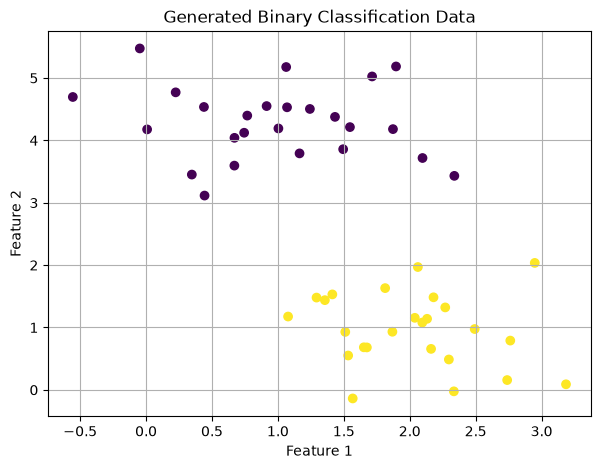

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=50,
    centers=2,
    random_state=0,
    cluster_std=0.60
)

plt.figure(figsize=(7, 5))
plt.grid(True)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated Binary Classification Data")
plt.show()

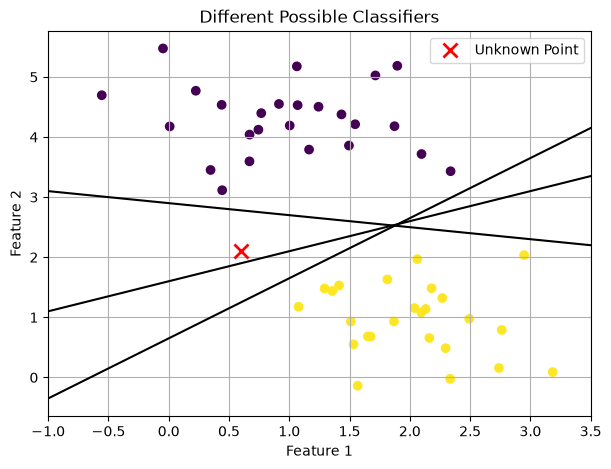

In [16]:
import numpy as np
import matplotlib.pyplot as plt

xfit = np.linspace(-1, 3.5, 100)

plt.figure(figsize=(7, 5))
plt.grid(True)
plt.scatter(X[:, 0], X[:, 1], c=y)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.plot(
    [0.6],
    [2.1],
    'x',
    color='red',
    markeredgewidth=2,
    markersize=10,
    label="Unknown Point"
)

plt.xlim(-1, 3.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Different Possible Classifiers")
plt.legend()
plt.show()

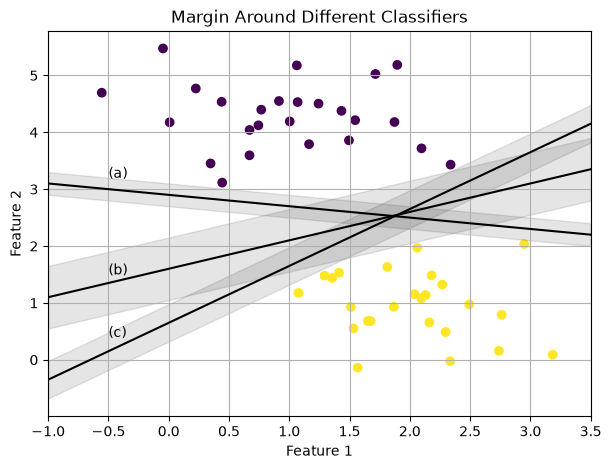

In [17]:
import numpy as np
import matplotlib.pyplot as plt

xfit = np.linspace(-1, 3.5, 100)

plt.figure(figsize=(7, 5))
plt.grid(True)
plt.scatter(X[:, 0], X[:, 1], c=y)

for label, m, b, d, text_y in [
    ("a", 1, 0.65, 0.33, 3.2),
    ("b", 0.5, 1.6, 0.55, 1.5),
    ("c", -0.2, 2.9, 0.2, 0.4)
]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(
        xfit,
        yfit - d,
        yfit + d,
        color='black',
        alpha=0.1
    )
    plt.annotate(f"({label})", xy=(-0.5, text_y))

plt.xlim(-1, 3.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Margin Around Different Classifiers")
plt.show()

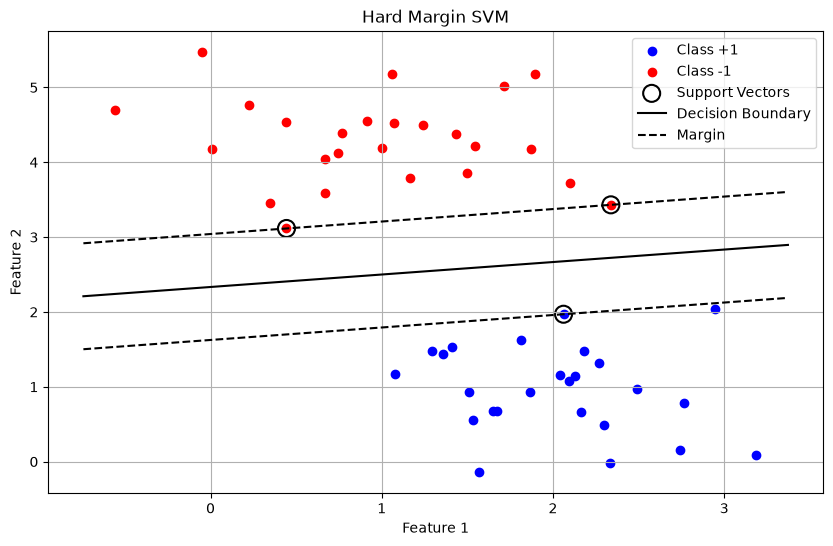

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix as cvxopt_matrix
from cvxopt import solvers as cvxopt_solvers
from sklearn.datasets import make_blobs

# Generate linearly separable data
X, y = make_blobs(
    n_samples=50,
    centers=2,
    random_state=0,
    cluster_std=0.60
)

# Convert labels from {0, 1} to {-1, 1}
y = 2 * y - 1

m, n = X.shape
y = y.reshape(-1, 1).astype(float)

# Compute H matrix
X_dash = y * X
H = np.dot(X_dash, X_dash.T)

# Convert to cvxopt format
P = cvxopt_matrix(H)
q = cvxopt_matrix(-np.ones((m, 1)))
G = cvxopt_matrix(-np.eye(m))
h = cvxopt_matrix(np.zeros(m))
A = cvxopt_matrix(y.reshape(1, -1))
b = cvxopt_matrix(np.zeros(1))

# Solver settings
cvxopt_solvers.options['show_progress'] = False

# Solve quadratic programming problem
solution = cvxopt_solvers.qp(P, q, G, h, A, b)
alphas = np.array(solution['x'])

# Calculate weight vector
w = ((y * alphas).T @ X).reshape(-1, 1)

# Find support vectors
support_vector_indices = (alphas > 1e-4).flatten()

# Calculate bias
b_value = y[support_vector_indices] - np.dot(X[support_vector_indices], w)
b_value = np.mean(b_value)

# Plot data
plt.figure(figsize=(10, 6))

plt.scatter(
    X[y.flatten() == 1, 0],
    X[y.flatten() == 1, 1],
    color='blue',
    label='Class +1'
)

plt.scatter(
    X[y.flatten() == -1, 0],
    X[y.flatten() == -1, 1],
    color='red',
    label='Class -1'
)

plt.scatter(
    X[support_vector_indices, 0],
    X[support_vector_indices, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='Support Vectors'
)

# Decision boundary
x_min, x_max = plt.xlim()
xx = np.linspace(x_min, x_max, 200)

w = w.flatten()
yy = (-w[0] * xx - b_value) / w[1]

# Margins
margin = 1 / np.linalg.norm(w)
yy_down = yy - margin * np.sqrt(1 + (w[0] / w[1]) ** 2)
yy_up = yy + margin * np.sqrt(1 + (w[0] / w[1]) ** 2)

plt.plot(xx, yy, 'k-', label='Decision Boundary')
plt.plot(xx, yy_down, 'k--', label='Margin')
plt.plot(xx, yy_up, 'k--')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hard Margin SVM')
plt.legend()
plt.grid(True)
plt.show()

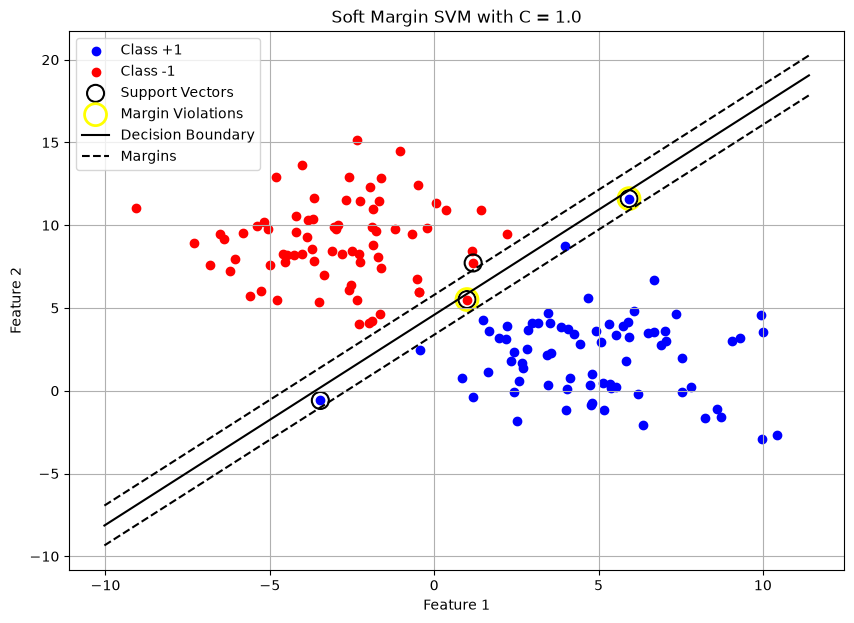

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix as cvxopt_matrix
from cvxopt import solvers as cvxopt_solvers
from sklearn.datasets import make_blobs

# Generate overlapping data
X, y = make_blobs(
    n_samples=150,
    centers=2,
    cluster_std=2.5,
    random_state=42
)

# Convert labels from {0, 1} to {-1, 1}
y = 2 * y - 1

m, n = X.shape
y = y.reshape(-1, 1).astype(float)

# Compute H matrix
X_dash = y * X
H = np.dot(X_dash, X_dash.T)

# Soft margin parameter
C = 1.0

# Convert to cvxopt format
P = cvxopt_matrix(H)
q = cvxopt_matrix(-np.ones((m, 1)))

# Constraints: 0 <= alpha <= C
G = cvxopt_matrix(np.vstack((-np.eye(m), np.eye(m))))
h = cvxopt_matrix(np.hstack((np.zeros(m), C * np.ones(m))))

A = cvxopt_matrix(y.reshape(1, -1))
b = cvxopt_matrix(np.zeros(1))

# Solver settings
cvxopt_solvers.options['show_progress'] = False

# Solve quadratic programming problem
solution = cvxopt_solvers.qp(P, q, G, h, A, b)
alphas = np.array(solution['x']).flatten()

# Calculate weight vector
w = ((y.flatten() * alphas) @ X).reshape(-1, 1)

# Support vectors
support_vector_indices = alphas > 1e-4

# Margin violations
violation_indices = alphas >= (C - 1e-5)

# Calculate bias using support vectors
b_value = np.mean(y[support_vector_indices] - X[support_vector_indices] @ w)

# Plot data
plt.figure(figsize=(10, 7))

plt.scatter(
    X[y.flatten() == 1, 0],
    X[y.flatten() == 1, 1],
    color='blue',
    label='Class +1'
)

plt.scatter(
    X[y.flatten() == -1, 0],
    X[y.flatten() == -1, 1],
    color='red',
    label='Class -1'
)

plt.scatter(
    X[support_vector_indices, 0],
    X[support_vector_indices, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='Support Vectors'
)

plt.scatter(
    X[violation_indices, 0],
    X[violation_indices, 1],
    s=250,
    facecolors='none',
    edgecolors='yellow',
    linewidths=2,
    label='Margin Violations'
)

# Decision boundary
x_min, x_max = plt.xlim()
xx = np.linspace(x_min, x_max, 300)

w_flat = w.flatten()
yy = (-w_flat[0] * xx - b_value) / w_flat[1]

# Margins
margin = 1 / np.linalg.norm(w_flat)
yy_down = yy - margin * np.sqrt(1 + (w_flat[0] / w_flat[1]) ** 2)
yy_up = yy + margin * np.sqrt(1 + (w_flat[0] / w_flat[1]) ** 2)

plt.plot(xx, yy, 'k-', label='Decision Boundary')
plt.plot(xx, yy_down, 'k--', label='Margins')
plt.plot(xx, yy_up, 'k--')

plt.title(f'Soft Margin SVM with C = {C}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

Accuracy: 1.0


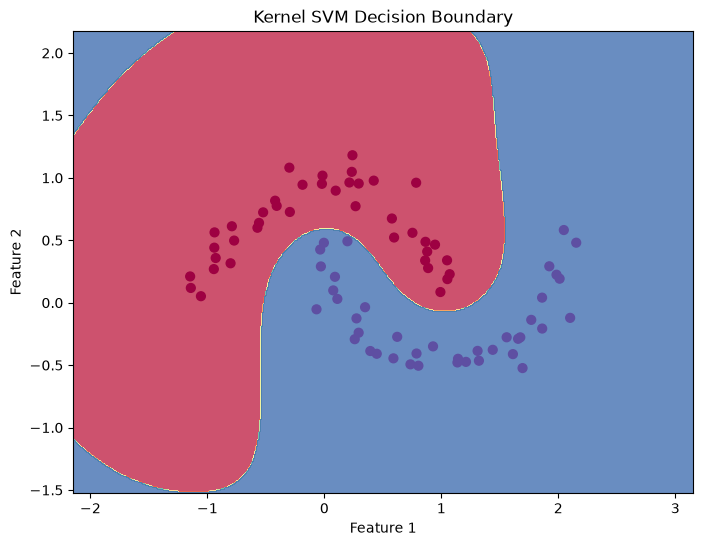

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cvxopt
from sklearn import datasets

# Kernel functions
def linear_kernel(x, z):
    return np.dot(x, z.T)

def polynomial_kernel(x, z, degree=5):
    return (1 + np.dot(x, z.T)) ** degree

def gaussian_kernel(x, z, sigma=0.5):
    return np.exp(
        -np.linalg.norm(x - z, axis=1) ** 2 / (2 * sigma ** 2)
    )

class SVM:
    def __init__(self, kernel=gaussian_kernel, C=1.0):
        self.kernel = kernel
        self.C = C

    def fit(self, X, y):
        self.X = X
        self.y = y

        m, n = X.shape

        # Kernel matrix
        K = np.zeros((m, m))

        for i in range(m):
            K[i, :] = self.kernel(X[i], X)

        self.K = K

        # Quadratic programming matrices
        P = cvxopt.matrix(np.outer(y, y) * K)
        q = cvxopt.matrix(-np.ones(m))

        G = cvxopt.matrix(np.vstack((-np.eye(m), np.eye(m))))
        h = cvxopt.matrix(np.hstack((np.zeros(m), np.ones(m) * self.C)))

        A = cvxopt.matrix(y.astype(float), (1, m))
        b = cvxopt.matrix(0.0)

        cvxopt.solvers.options["show_progress"] = False

        solution = cvxopt.solvers.qp(P, q, G, h, A, b)

        self.alphas = np.array(solution["x"]).flatten()

        # Support vectors
        threshold = 1e-5
        self.support_vector_indices = self.alphas > threshold

        # Margin support vectors
        margin_sv = (self.alphas > threshold) & (self.alphas < self.C - threshold)

        if np.any(margin_sv):
            selected_sv = margin_sv
        else:
            selected_sv = self.support_vector_indices

        # Calculate bias
        b_values = []

        for index in np.where(selected_sv)[0]:
            prediction = np.sum(
                self.alphas[self.support_vector_indices]
                * self.y[self.support_vector_indices]
                * self.kernel(self.X[index], self.X[self.support_vector_indices])
            )

            b_values.append(self.y[index] - prediction)

        self.b = np.mean(b_values)

    def predict(self, X_test):
        predictions = []

        for x in X_test:
            result = np.sum(
                self.alphas[self.support_vector_indices]
                * self.y[self.support_vector_indices]
                * self.kernel(x, self.X[self.support_vector_indices])
            )

            predictions.append(np.sign(result + self.b))

        return np.array(predictions)

def plot_contour(X, y, svm):
    h = 0.01

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    points = np.c_[xx.ravel(), yy.ravel()]

    Z = svm.predict(points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
    plt.title("Kernel SVM Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Generate non-linear moon-shaped data
X, y = datasets.make_moons(
    n_samples=80,
    noise=0.1,
    random_state=0
)

# Convert labels from {0, 1} to {-1, 1}
y[y == 0] = -1

# Train SVM with Gaussian kernel
svm = SVM(kernel=gaussian_kernel, C=1.0)
svm.fit(X, y)

# Predict
y_pred = svm.predict(X)

# Accuracy
accuracy = np.mean(y == y_pred)

print("Accuracy:", accuracy)

# Plot result
plot_contour(X, y, svm)

Discussion

In this lab, Support Vector Machine was implemented and studied using Python. First, a simple binary classification dataset was generated and different possible separating lines were plotted. This showed that many lines can separate the same data, but SVM selects the line with the maximum margin. Then, hard margin SVM was implemented for linearly separable data, where support vectors were identified and the decision boundary with margin lines was plotted. After that, soft margin SVM was applied to overlapping data, where some points were allowed to violate the margin. This showed that soft margin SVM is more practical for real-world datasets. Finally, kernel SVM was implemented using a Gaussian kernel to classify non-linear moon-shaped data. The result showed that kernel functions allow SVM to create non-linear decision boundaries and classify complex data patterns effectively.
----

Conclusion

From this lab, it was concluded that Support Vector Machine is an effective classification algorithm that works by finding the optimal hyperplane with the maximum margin. Hard margin SVM is suitable for perfectly separable data, while soft margin SVM is better for noisy or overlapping data because it allows limited misclassification. The use of kernel functions makes SVM powerful for non-linear classification problems. Overall, the lab helped in understanding the role of margins, support vectors, soft margin parameter C, and kernel functions in building an accurate SVM classifier.